# PresyoPH – Exploratory Checks on CPI

**Series:** national CPI, *0 - All Items* (2018 = 100), January 2018 – August 2026, from the PSA OpenSTAT exports in `datasets/raw/`.

**Why only CPI:** following the proposal, CPI is the sole forecasting target. Under option B, forecasted inflation and purchasing power are derived from the CPI forecast, so the checks below are run on CPI only. Section 2 confirms that the derivation reproduces PSA's published figures.

**Checks:**
1. Load the series
2. Validate option B (derived vs. published inflation and purchasing power)
3. Trend
4. Stationarity (ADF and KPSS)
5. Seasonality (STL decomposition, month-of-year pattern)
6. Autocorrelation (ACF and PACF)
7. Volatility and unusual periods
8. Summary of findings

Figures are saved to `reports/figures/` for the documentation.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from modeling.temp_loader import load_cpi, load_inflation, load_purchasing_power
from modeling.derive import to_inflation, to_purchasing_power

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", "{:.4f}".format)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Load the series

In [2]:
cpi = load_cpi()
print(f"Observations: {len(cpi)}  ({cpi.index.min():%b %Y} – {cpi.index.max():%b %Y})")
print(f"Missing values: {cpi.isna().sum()}")
cpi.describe().to_frame().T

Observations: 104  (Jan 2018 – Aug 2026)
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
cpi,104.0000,115.0913,11.5324,97.2000,103.8750,113.6500,125.7750,136.5000


## 2. Validate option B

Inflation and purchasing power are derived from CPI with PSA's formulas:

- inflation (%) = (CPI<sub>t</sub> / CPI<sub>t−12</sub> − 1) × 100, rounded to 1 decimal
- purchasing power = 100 / CPI<sub>t</sub>, rounded to 2 decimals

If the derived values match PSA's published series, forecasting CPI alone is enough to produce all three forecasts.

In [3]:
published_inf = load_inflation()
published_pp = load_purchasing_power()

diff_inf = (to_inflation(cpi) - published_inf).dropna()
diff_pp = (to_purchasing_power(cpi) - published_pp).dropna()

pd.DataFrame({
    "months compared": [len(diff_inf), len(diff_pp)],
    "max abs difference": [diff_inf.abs().max(), diff_pp.abs().max()],
    "months that differ": [(diff_inf.abs() > 1e-9).sum(), (diff_pp.abs() > 1e-9).sum()],
}, index=["inflation", "purchasing power"])

,months compared,max abs difference,months that differ
inflation,92,0.0000,0
purchasing power,104,0.0000,0


## 3. Trend

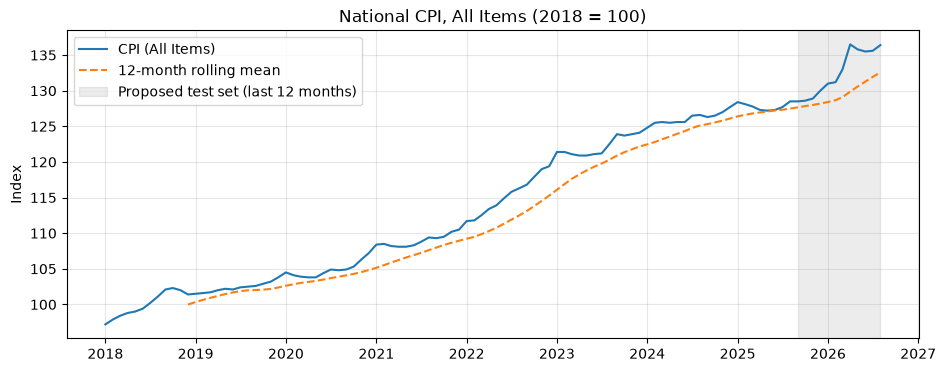

,first,last,mean,change within year (%)
date,,,,
2018,97.2000,101.4000,99.9833,4.3210
2019,101.5000,103.8000,102.3750,2.2660
2020,104.5000,107.2000,104.8250,2.5837
2021,108.4000,110.5000,108.9417,1.9373
2022,111.7000,119.4000,115.2833,6.8935
2023,121.4000,124.1000,122.1750,2.2241
2024,124.8000,127.7000,126.1000,2.3237
2025,128.4000,130.0000,128.1917,1.2461
2026,131.0000,136.4000,134.3750,4.1221


In [4]:
proposed_test_start = cpi.index[-12]

fig, ax = plt.subplots()
ax.plot(cpi, label="CPI (All Items)")
ax.plot(cpi.rolling(12).mean(), label="12-month rolling mean", linestyle="--")
ax.axvspan(proposed_test_start, cpi.index[-1], color="grey", alpha=0.15, label="Proposed test set (last 12 months)")
ax.set_title("National CPI, All Items (2018 = 100)")
ax.set_ylabel("Index")
ax.legend()
save(fig, "01_cpi_trend")
plt.show()

yearly = cpi.groupby(cpi.index.year).agg(["first", "last", "mean"])
yearly["change within year (%)"] = (yearly["last"] / yearly["first"] - 1) * 100
yearly

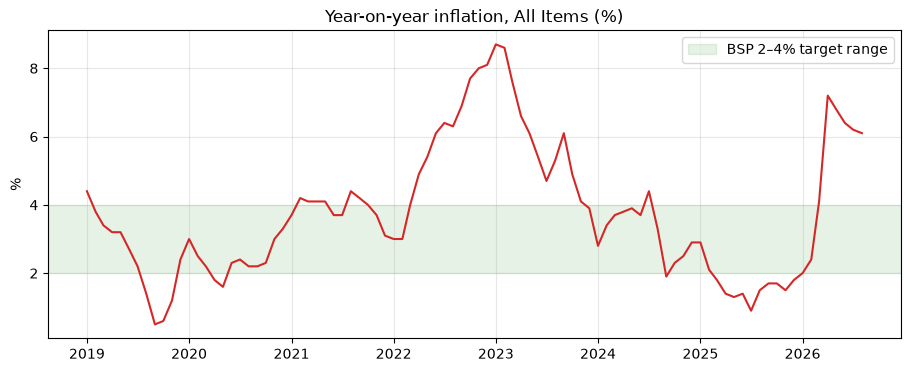

In [5]:
fig, ax = plt.subplots()
ax.plot(published_inf, color="tab:red")
ax.axhspan(2, 4, color="green", alpha=0.1, label="BSP 2–4% target range")
ax.set_title("Year-on-year inflation, All Items (%)")
ax.set_ylabel("%")
ax.legend()
save(fig, "02_inflation_context")
plt.show()

## 4. Stationarity

Two complementary tests, run on the level, the first difference, and the first + seasonal (lag-12) difference:

| Test | Null hypothesis | p < 0.05 means |
|---|---|---|
| ADF | the series has a unit root (non-stationary) | stationary |
| KPSS | the series is stationary | non-stationary |

A series is treated as stationary when **both** agree (ADF rejects, KPSS does not). This decides the differencing order *d* (and *D*) for ARIMA.

In [6]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

def stationarity_tests(series, name):
    series = series.dropna()
    adf_stat, adf_p, adf_lags, *_ = adfuller(series, autolag="AIC", result_object=False)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto", result_object=False)
    return {
        "series": name,
        "n": len(series),
        "ADF stat": adf_stat,
        "ADF p": adf_p,
        "KPSS stat": kpss_stat,
        "KPSS p": kpss_p,
        "stationary?": "yes" if adf_p < 0.05 and kpss_p >= 0.05 else "no",
    }

diff1 = cpi.diff()
diff1_12 = cpi.diff().diff(12)

stationarity = pd.DataFrame([
    stationarity_tests(cpi, "level"),
    stationarity_tests(diff1, "first difference (d=1)"),
    stationarity_tests(diff1_12, "first + seasonal difference (d=1, D=1)"),
]).set_index("series")
stationarity

,n,ADF stat,ADF p,KPSS stat,KPSS p,stationary?
series,,,,,,
level,104,0.7364,0.9905,1.5863,0.0100,no
first difference (d=1),103,-6.9941,0.0000,0.1420,0.1000,yes
"first + seasonal difference (d=1, D=1)",91,-2.8071,0.0573,0.1115,0.1000,no


*Note: statsmodels caps KPSS p-values to the range 0.01–0.10, so a reported 0.10 means "0.10 or higher" and 0.01 means "0.01 or lower".*

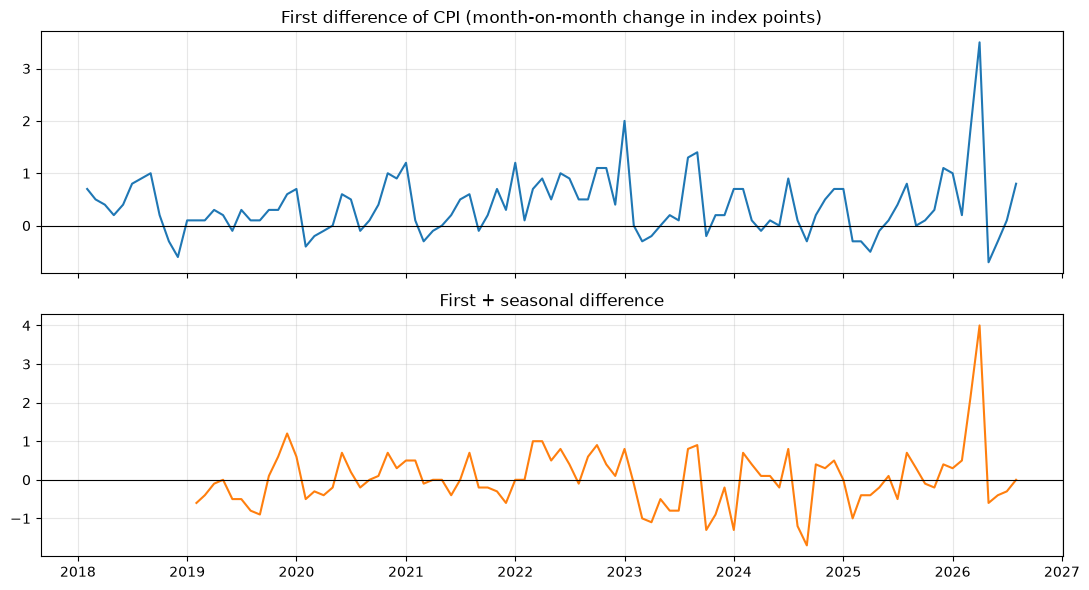

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(diff1)
axes[0].set_title("First difference of CPI (month-on-month change in index points)")
axes[1].plot(diff1_12, color="tab:orange")
axes[1].set_title("First + seasonal difference")
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
fig.tight_layout()
save(fig, "03_differenced_series")
plt.show()

In [8]:
from statsmodels.tsa.stattools import acf

acf_d1_12 = acf(diff1_12.dropna(), nlags=12)
print(f"ACF at lag 12 after first + seasonal difference: {acf_d1_12[12]:.3f}")
print("(a strong negative value at the seasonal lag is a typical sign of over-differencing)")

ACF at lag 12 after first + seasonal difference: -0.305
(a strong negative value at the seasonal lag is a typical sign of over-differencing)


## 5. Seasonality

- **STL decomposition** (period 12, robust) splits CPI into trend, seasonal, and remainder parts.
- **Strength of seasonality** F<sub>S</sub> = max(0, 1 − Var(R) / Var(S + R)) and **strength of trend** F<sub>T</sub> = max(0, 1 − Var(R) / Var(T + R)) (Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*). Values near 0 mean weak; above about 0.6 is usually considered strong.
- **Month-of-year pattern** of the month-on-month % change, with a Kruskal–Wallis test of whether the calendar month matters.

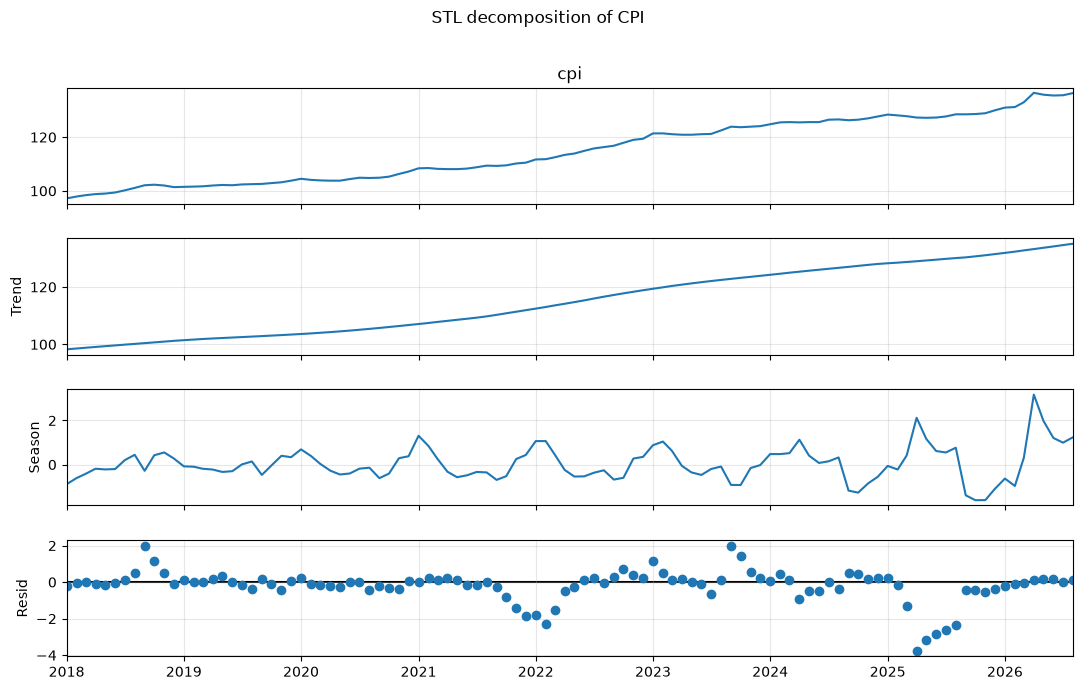

,value
strength of trend (F_T),0.9940
strength of seasonality (F_S),0.1680
seasonal amplitude (index points),4.7887


In [9]:
stl = STL(cpi, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(11, 7)
fig.suptitle("STL decomposition of CPI", y=1.02)
save(fig, "04_stl_decomposition")
plt.show()

var_r = np.var(stl.resid)
strength = pd.Series({
    "strength of trend (F_T)": max(0, 1 - var_r / np.var(stl.trend + stl.resid)),
    "strength of seasonality (F_S)": max(0, 1 - var_r / np.var(stl.seasonal + stl.resid)),
    "seasonal amplitude (index points)": stl.seasonal.max() - stl.seasonal.min(),
})
strength.to_frame("value")

In [10]:
seasonal = stl.seasonal
seasonal.groupby(seasonal.index.year).agg(lambda s: s.max() - s.min()).to_frame("seasonal swing within year (index points)")

,seasonal swing within year (index points)
date,
2018,1.4401
2019,0.8679
2020,1.3041
2021,2.0006
2022,1.7461
2023,1.9710
2024,2.4007
2025,3.7382
2026,4.1429


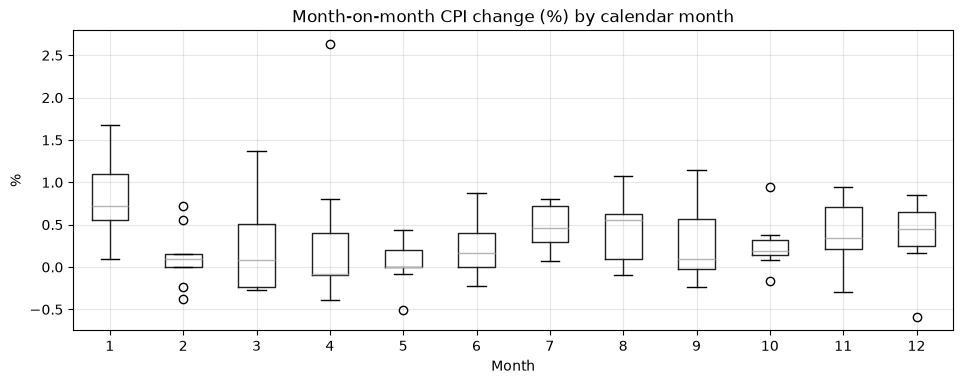

Kruskal–Wallis across calendar months: H = 20.50, p = 0.0389


month,1,2,3,4,5,6,7,8,9,10,11,12
mean,0.8169,0.1220,0.1930,0.3676,0.0364,0.2189,0.4455,0.4724,0.3033,0.2586,0.4138,0.3768
median,0.7218,0.0923,0.0797,-0.0796,0.0000,0.1654,0.4617,0.5515,0.0965,0.1894,0.3434,0.4437
std,0.4743,0.3446,0.5529,0.9223,0.2592,0.3469,0.2802,0.3880,0.5094,0.3189,0.4173,0.4645


In [11]:
mom = cpi.pct_change().mul(100).dropna().to_frame("mom")
mom["month"] = mom.index.month

fig, ax = plt.subplots()
mom.boxplot(column="mom", by="month", ax=ax)
ax.set_title("Month-on-month CPI change (%) by calendar month")
ax.set_xlabel("Month")
ax.set_ylabel("%")
fig.suptitle("")
save(fig, "05_month_of_year")
plt.show()

groups = [g["mom"].values for _, g in mom.groupby("month")]
kw_stat, kw_p = stats.kruskal(*groups)
print(f"Kruskal–Wallis across calendar months: H = {kw_stat:.2f}, p = {kw_p:.4f}")
mom.groupby("month")["mom"].agg(["mean", "median", "std"]).T

## 6. Autocorrelation

ACF and PACF of the first-differenced series guide the ARIMA orders:

- a sharp PACF cut-off after lag *p* suggests AR(*p*); a sharp ACF cut-off after lag *q* suggests MA(*q*)
- spikes at lags 12, 24, 36 suggest seasonal terms

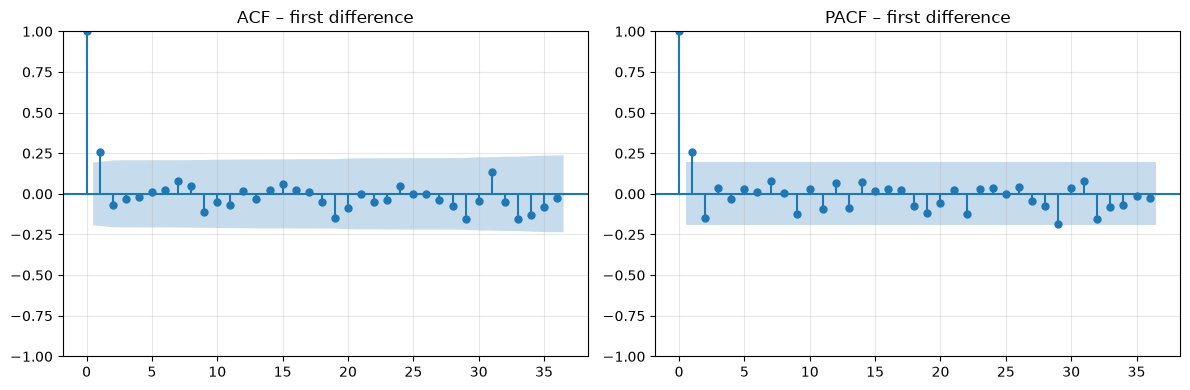

,lb_stat,lb_pvalue
6,7.8401,0.2501
12,11.1618,0.5151
24,17.0121,0.8481


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(diff1.dropna(), lags=36, ax=axes[0], title="ACF – first difference")
plot_pacf(diff1.dropna(), lags=36, ax=axes[1], title="PACF – first difference", method="ywm")
fig.tight_layout()
save(fig, "06_acf_pacf")
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(diff1.dropna(), lags=[6, 12, 24], return_df=True)

## 7. Volatility and unusual periods

The rolling 12-month standard deviation of the month-on-month change shows when CPI moved unusually fast. Such periods matter because Linear Regression and Moving Average cannot adapt to them, and because the test set's behaviour depends on whether it falls in a calm or volatile period.

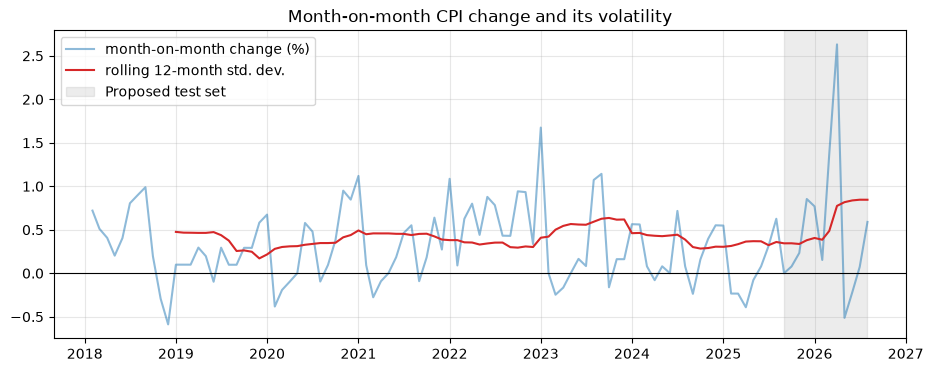

,largest month-on-month changes (%)
date,
2018-09-01,0.9891
2021-01-01,1.1194
2022-01-01,1.0860
2023-01-01,1.6750
2023-08-01,1.0726
2023-09-01,1.1429
2026-03-01,1.3720
2026-04-01,2.6316


In [13]:
rolling_sd = mom["mom"].rolling(12).std()

fig, ax = plt.subplots()
ax.plot(mom["mom"], alpha=0.5, label="month-on-month change (%)")
ax.plot(rolling_sd, color="tab:red", label="rolling 12-month std. dev.")
ax.axvspan(proposed_test_start, cpi.index[-1], color="grey", alpha=0.15, label="Proposed test set")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-on-month CPI change and its volatility")
ax.legend()
save(fig, "07_volatility")
plt.show()

top = mom["mom"].abs().nlargest(8).index
mom.loc[top, ["mom"]].sort_index().rename(columns={"mom": "largest month-on-month changes (%)"})

In [14]:
periods = {
    "2018 (pre-pandemic)": ("2018-01", "2018-12"),
    "2019": ("2019-01", "2019-12"),
    "2020–2021 (pandemic)": ("2020-01", "2021-12"),
    "2022–2023 (price surge)": ("2022-01", "2023-12"),
    "2024–Aug 2025 (training tail)": ("2024-01", "2025-08"),
    "Sep 2025–Aug 2026 (proposed test)": ("2025-09", "2026-08"),
}
pd.DataFrame({
    name: {
        "mean MoM change (%)": mom.loc[a:b, "mom"].mean(),
        "std MoM change (%)": mom.loc[a:b, "mom"].std(),
        "mean YoY inflation (%)": published_inf.loc[a:b].mean(),
    }
    for name, (a, b) in periods.items()
}).T

,mean MoM change (%),std MoM change (%),mean YoY inflation (%)
2018 (pre-pandemic),0.3864,0.4909,NaN
2019,0.1953,0.1707,2.4167
2020–2021 (pandemic),0.2617,0.4050,3.1583
2022–2023 (price surge),0.4860,0.5036,5.9083
2024–Aug 2025 (training tail),0.1749,0.3378,2.5950
Sep 2025–Aug 2026 (proposed test),0.5017,0.8451,3.9917


The proposed test period, month by month:

In [15]:
pd.DataFrame({
    "CPI": cpi,
    "MoM change (%)": cpi.pct_change() * 100,
    "YoY inflation (%)": published_inf,
}).loc["2025-06":].round(2)

,CPI,MoM change (%),YoY inflation (%)
date,,,
2025-06-01,127.3000,0.0800,1.4000
2025-07-01,127.7000,0.3100,0.9000
2025-08-01,128.5000,0.6300,1.5000
2025-09-01,128.5000,0.0000,1.7000
2025-10-01,128.6000,0.0800,1.7000
2025-11-01,128.9000,0.2300,1.5000
2025-12-01,130.0000,0.8500,1.8000
2026-01-01,131.0000,0.7700,2.0000
2026-02-01,131.2000,0.1500,2.4000


## 8. Summary of findings

*Draft based on the outputs above. Review it, and rewrite it in your own words, before using it in the documentation.*

**Trend.** CPI rose from 97.2 (Jan 2018) to 136.4 (Aug 2026), about 40% overall. The trend is strong and almost entirely upward (strength of trend F<sub>T</sub> ≈ 0.99). The fastest rise within a year was in 2022 (+6.9%), followed by 2018 (+4.3%) and Jan–Aug 2026 (+4.1% in only eight months).

**Stationarity.** The level is non-stationary (ADF p ≈ 0.99; KPSS p ≤ 0.01). After one difference, both tests agree the series is stationary (ADF p < 0.001; KPSS p ≥ 0.10). Adding a seasonal difference makes the ADF result borderline (p ≈ 0.057), and the ACF of the doubly differenced series shows a strong negative spike at lag 12 (−0.31), a typical sign of over-differencing. **→ Use d = 1 and no seasonal differencing (D = 0).**

**Seasonality.** Seasonality is weak: F<sub>S</sub> ≈ 0.17. The seasonal component's yearly swing stayed below 2.5 index points through 2024 (0.9–2.4), against a 39-point rise over the whole period; its larger values in 2025–2026 reflect the 2026 price shock rather than a stronger seasonal pattern. The calendar-month effect is only marginally significant (Kruskal–Wallis p ≈ 0.039), driven mainly by January, which has the highest average month-on-month increase (≈ 0.8%). The ACF and PACF show no spikes at lags 12, 24, or 36. **→ Seasonality is weak: the non-seasonal model is preferred at the test origin and in the final refit, although a seasonal AR term was chosen in some earlier folds (see notebook 02). A small seasonal candidate is therefore kept in the ARIMA grid search.**

**Autocorrelation.** Both the ACF and PACF of the first difference have one significant spike at lag 1 (≈ 0.26) and nothing notable afterwards. The Ljung–Box test finds no significant remaining autocorrelation at lags 6, 12, or 24. **→ Candidate models are low-order: ARIMA(0,1,0), (1,1,0), (0,1,1), and (1,1,1), each with drift; a grid of p, q ∈ {0, 1, 2} is enough.**

**Unusual periods.** Month-on-month changes were most volatile in 2018, during 2022–2023, and above all in the proposed test period. In March–April 2026 CPI jumped by 1.4% and then 2.6% in a single month, and year-on-year inflation rose from 2.4% (Feb 2026) to 7.2% (Apr 2026). The proposed test period is about 2.5 times as volatile as the end of the training data (std. dev. of month-on-month change 0.85% vs. 0.34%).

**Implications for modeling.**
- None of the three models can anticipate the March–April 2026 shock from past CPI alone, which matches the proposal's limitation on external factors. Because CPI stayed at its new level after April, forecast errors are expected to stay large from March to August 2026, about half of the test period, so the results should be reported and discussed with this in mind.
- Linear Regression on a time index will underestimate the jump; Moving Average will lag behind it; ARIMA with drift will follow the level more closely but will still miss the shock itself.
- The 12-month test set still covers one full seasonal cycle. The team should decide whether to keep it as the single evaluation period or to add a second check (for example, rolling-origin evaluation) so the chosen model does not depend on one unusual period.